# Лабораторная работа 4. Бинаризация и выделение границ

**Задание:** Добиться перевода текста на картике в гугл и яндекс переводчиках. (изображение выдается преподавателем)

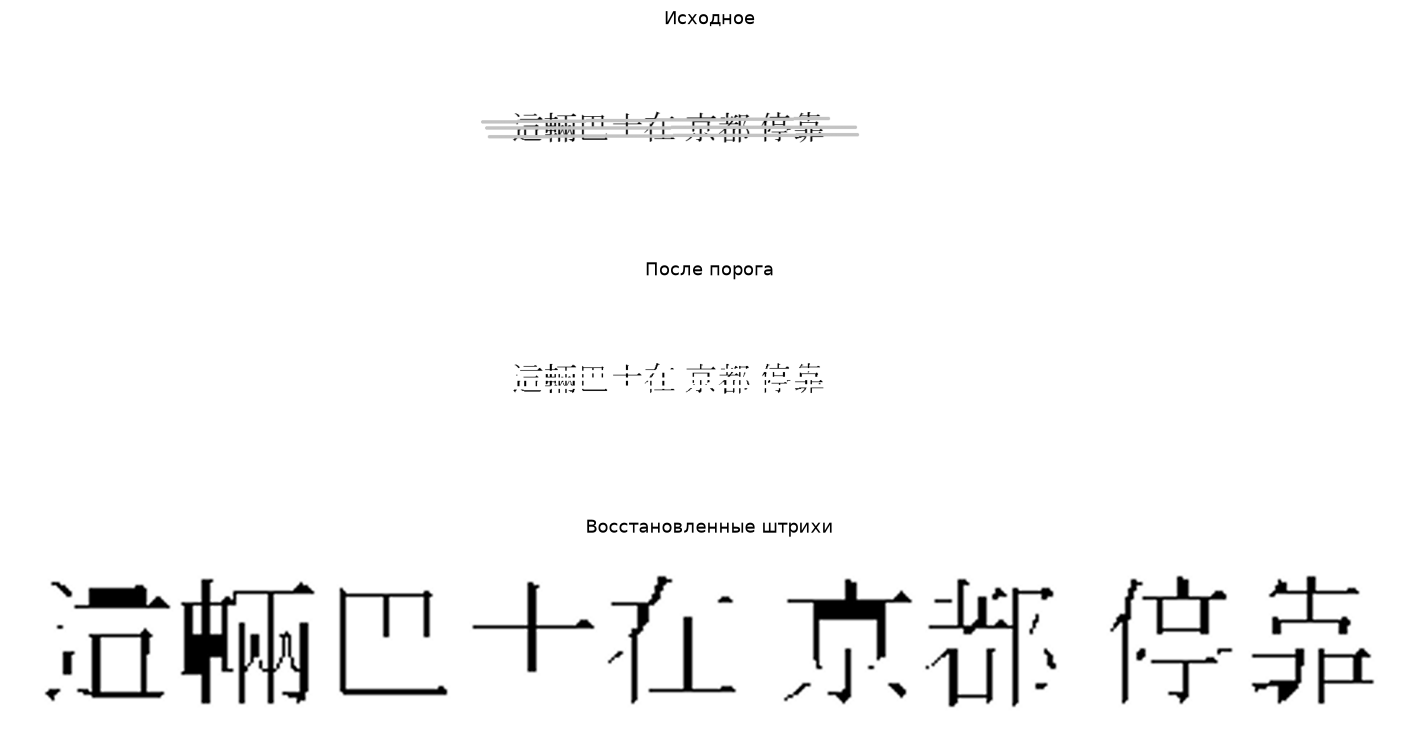

In [2]:
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np

# Загружаем изображение с иероглифами в оттенках серого.
image = cv.imread('4_as.png', cv.IMREAD_GRAYSCALE)
if image is None:
    raise FileNotFoundError('4_as.png')

# Порог делает светло-серые полосы белыми, а темные иероглифы оставляет черными.
_, binary = cv.threshold(image, 100, 255, cv.THRESH_BINARY)
ink = cv.bitwise_not(binary)
# Вертикальное замыкание соединяет штрихи, разорванные удаленными полосами.
ink = cv.morphologyEx(ink, cv.MORPH_CLOSE, np.ones((7, 1), np.uint8))
restored = cv.bitwise_not(ink)

# Находим границы текста и оставляем небольшой отступ вокруг него.
ys, xs = np.where(ink > 0)
padding = 12
left = max(0, xs.min() - padding)
right = min(ink.shape[1], xs.max() + padding + 1)
top = max(0, ys.min() - padding)
bottom = min(ink.shape[0], ys.max() + padding + 1)
cropped = restored[top:bottom, left:right]
# Увеличиваем текст для распознавания в переводчиках.
prepared = cv.resize(cropped, None, fx=4, fy=4, interpolation=cv.INTER_CUBIC)

# Показываем этапы обработки для сравнения.
fig, axes = plt.subplots(3, 1, figsize=(13, 7))
for ax, (title, picture) in zip(axes, [
    ('Исходное', image), ('После порога', binary), ('Восстановленные штрихи', prepared),
]):
    ax.imshow(picture, cmap='gray', vmin=0, vmax=255)
    ax.set_title(title)
    ax.axis('off')
plt.tight_layout()
plt.show()

# Этот файл загружается в Google и Яндекс Переводчик.
cv.imwrite('lab4_text_for_translate.png', prepared)


![Подготовленный текст](lab4_text_for_translate.png)

### Перевод подготовленного изображения

| Переводчик | Распознанный текст | Перевод |
|---|---|---|
| Google | 這輛巴士在京都停靠 | Этот автобус остановился в Киото. |
| Яндекс | 這啊巴十在 京都停靠 | Этот автобус останавливается в Киото. |